In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.ticker as mticker
from prophet import Prophet

In [2]:
data = pd.read_csv('Cola.csv')
display(data)

,Date,Close/Last,Volume,Open,High,Low
0,12/31/2024,$62.26,9256664,$62.02,$62.43,$61.80
1,12/30/2024,$62.03,8972212,$62.34,$62.34,$61.68
2,12/27/2024,$62.45,8542773,$62.45,$62.95,$62.209
3,12/26/2024,$62.57,7945641,$62.62,$62.74,$62.40
4,12/24/2024,$62.84,5019131,$62.20,$62.84,$62.01
...,...,...,...,...,...,...
1253,01/08/2020,$54.35,10676710,$54.27,$54.64,$54.15
1254,01/07/2020,$54.25,10230670,$54.45,$54.60,$54.15
1255,01/06/2020,$54.67,14698440,$54.65,$54.905,$54.52
1256,01/03/2020,$54.69,11354500,$54.32,$54.99,$54.09


In [3]:
data['Date'] = pd.to_datetime(data['Date'])
data['Close/Last'] = data['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

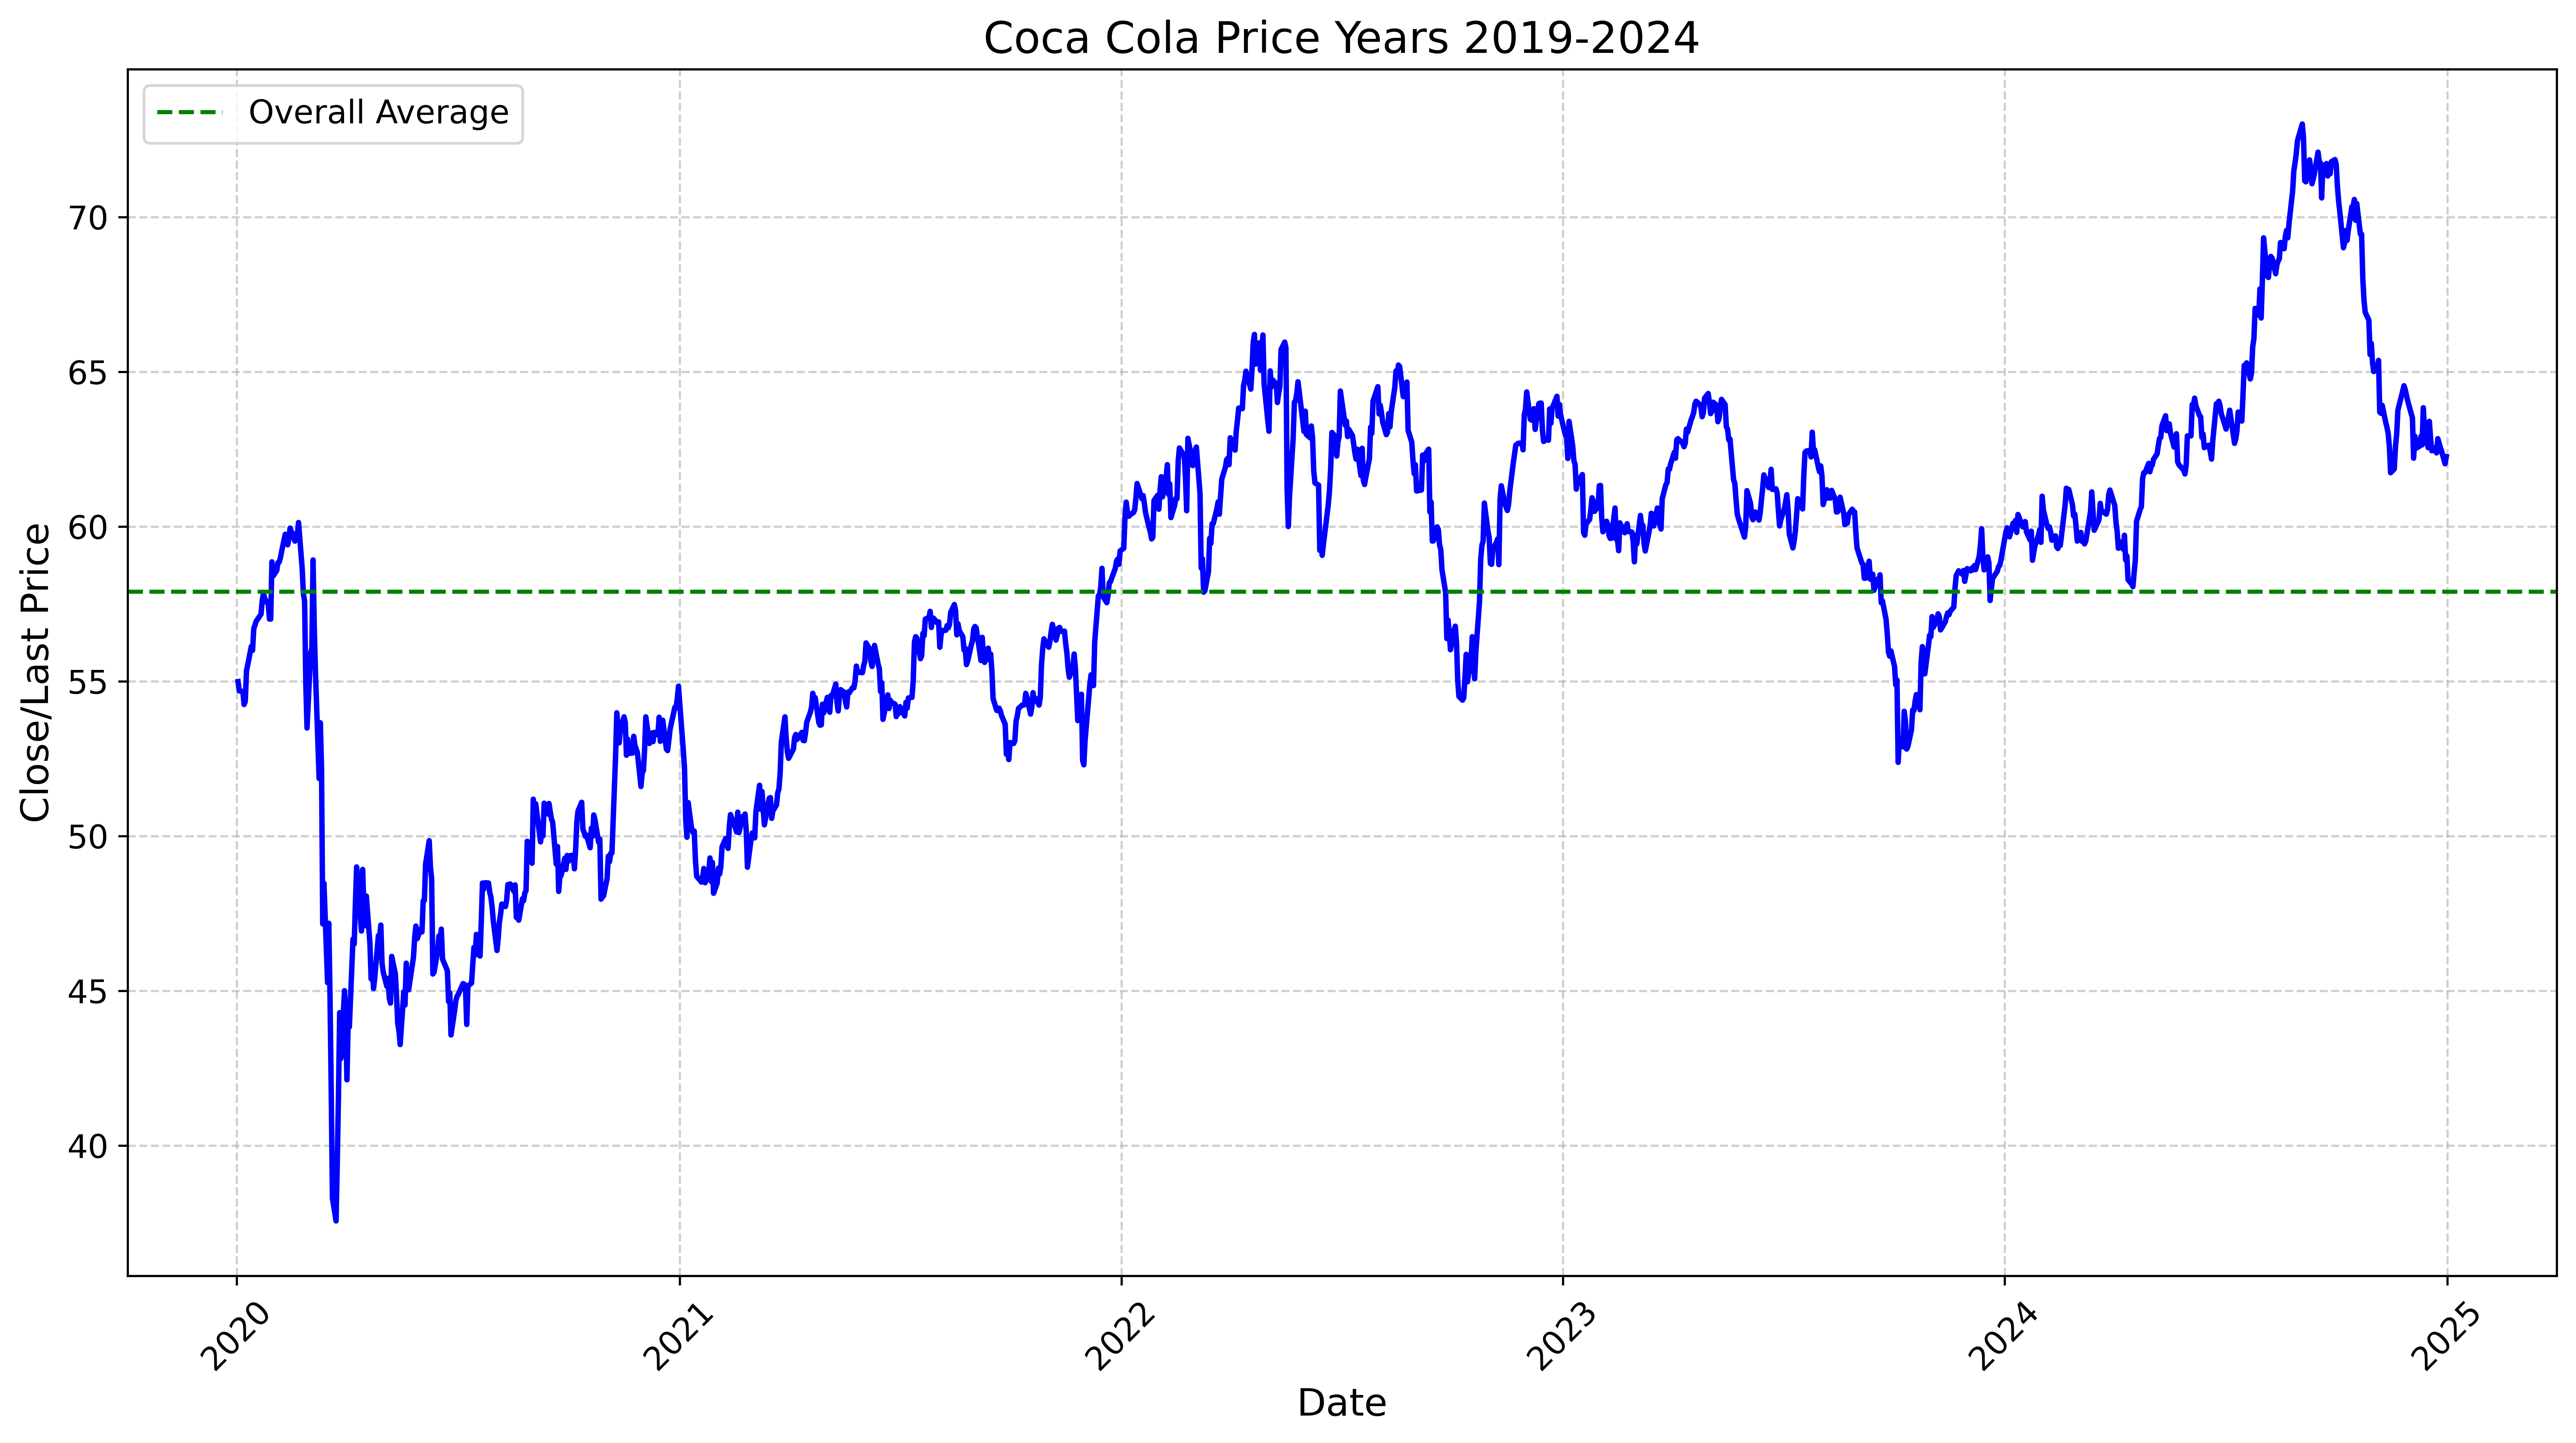

In [4]:
%config InlineBackend.figure_format = 'retina'

plt.figure(figsize=(16, 8), dpi = 300)

plt.plot(data['Date'], data['Close/Last'], linewidth=2, color = 'blue')

overall_avg = data['Close/Last'].mean()
plt.axhline(overall_avg, color='green', linestyle='--', label='Overall Average')

plt.title('Coca Cola Price Years 2019-2024', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close/Last Price', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)
plt.show()

Coca-Cola (ticker: KO) has long been seen as a reliable choice among large consumer goods companies. One key reason is that Coca-Cola has an incredibly strong brand, known around the world, plus a broad range of products—like sodas, juices, teas, coffees, and bottled water—that helps it navigate ups and downs in different markets. Investors who want regular income often find Coca-Cola attractive because of its solid dividend track record and commitment to rewarding shareholders. Even with major market shake-ups—like the drop in early 2020— the stock has repeatedly shown that it can bounce back and move above its long-term average. This resilience reflects its “defensive” nature: people tend to keep buying drinks even if the economy struggles, so Coca-Cola’s earnings often remain fairly stable.

Looking ahead, while demand for traditional soft drinks may slow in some regions, there’s still growth potential in emerging markets, innovative products, and smart acquisitions. Coca-Cola’s focus on partnerships, new marketing strategies, and cost-cutting measures also sets it up for gradual, long-term growth. Of course, no investment is ever completely risk-free, and careful research is always a must. But thanks to its global reputation, wide-ranging product lineup, steady dividend, and record of bouncing back from market dips, Coca-Cola remains a solid pick for investors looking for both stable income and modest growth potential.

From 2019 to 2024, Coca-Cola’s share price has gone through notable ups and downs, with the most dramatic drop occurring in early 2020 when COVID-19 rattled markets and briefly pulled the stock below 40. However, the company rebounded relatively quickly, underscoring its strong global brand and steady dividend history. Over the following two years, the price trended upward, often resting near or above its overall average (shown by the green dashed line), though there were intermittent dips tied to broader market events. By late 2023, the stock hit a new high of around $70 before settling back down, but it still remained comfortably above pandemic lows. Overall, the chart highlights Coca-Cola’s resilience and supports its reputation as a “defensive” stock—one that, despite occasional volatility, has consistently managed to recoup losses and carry on an upward path in the face of wider economic challenges.

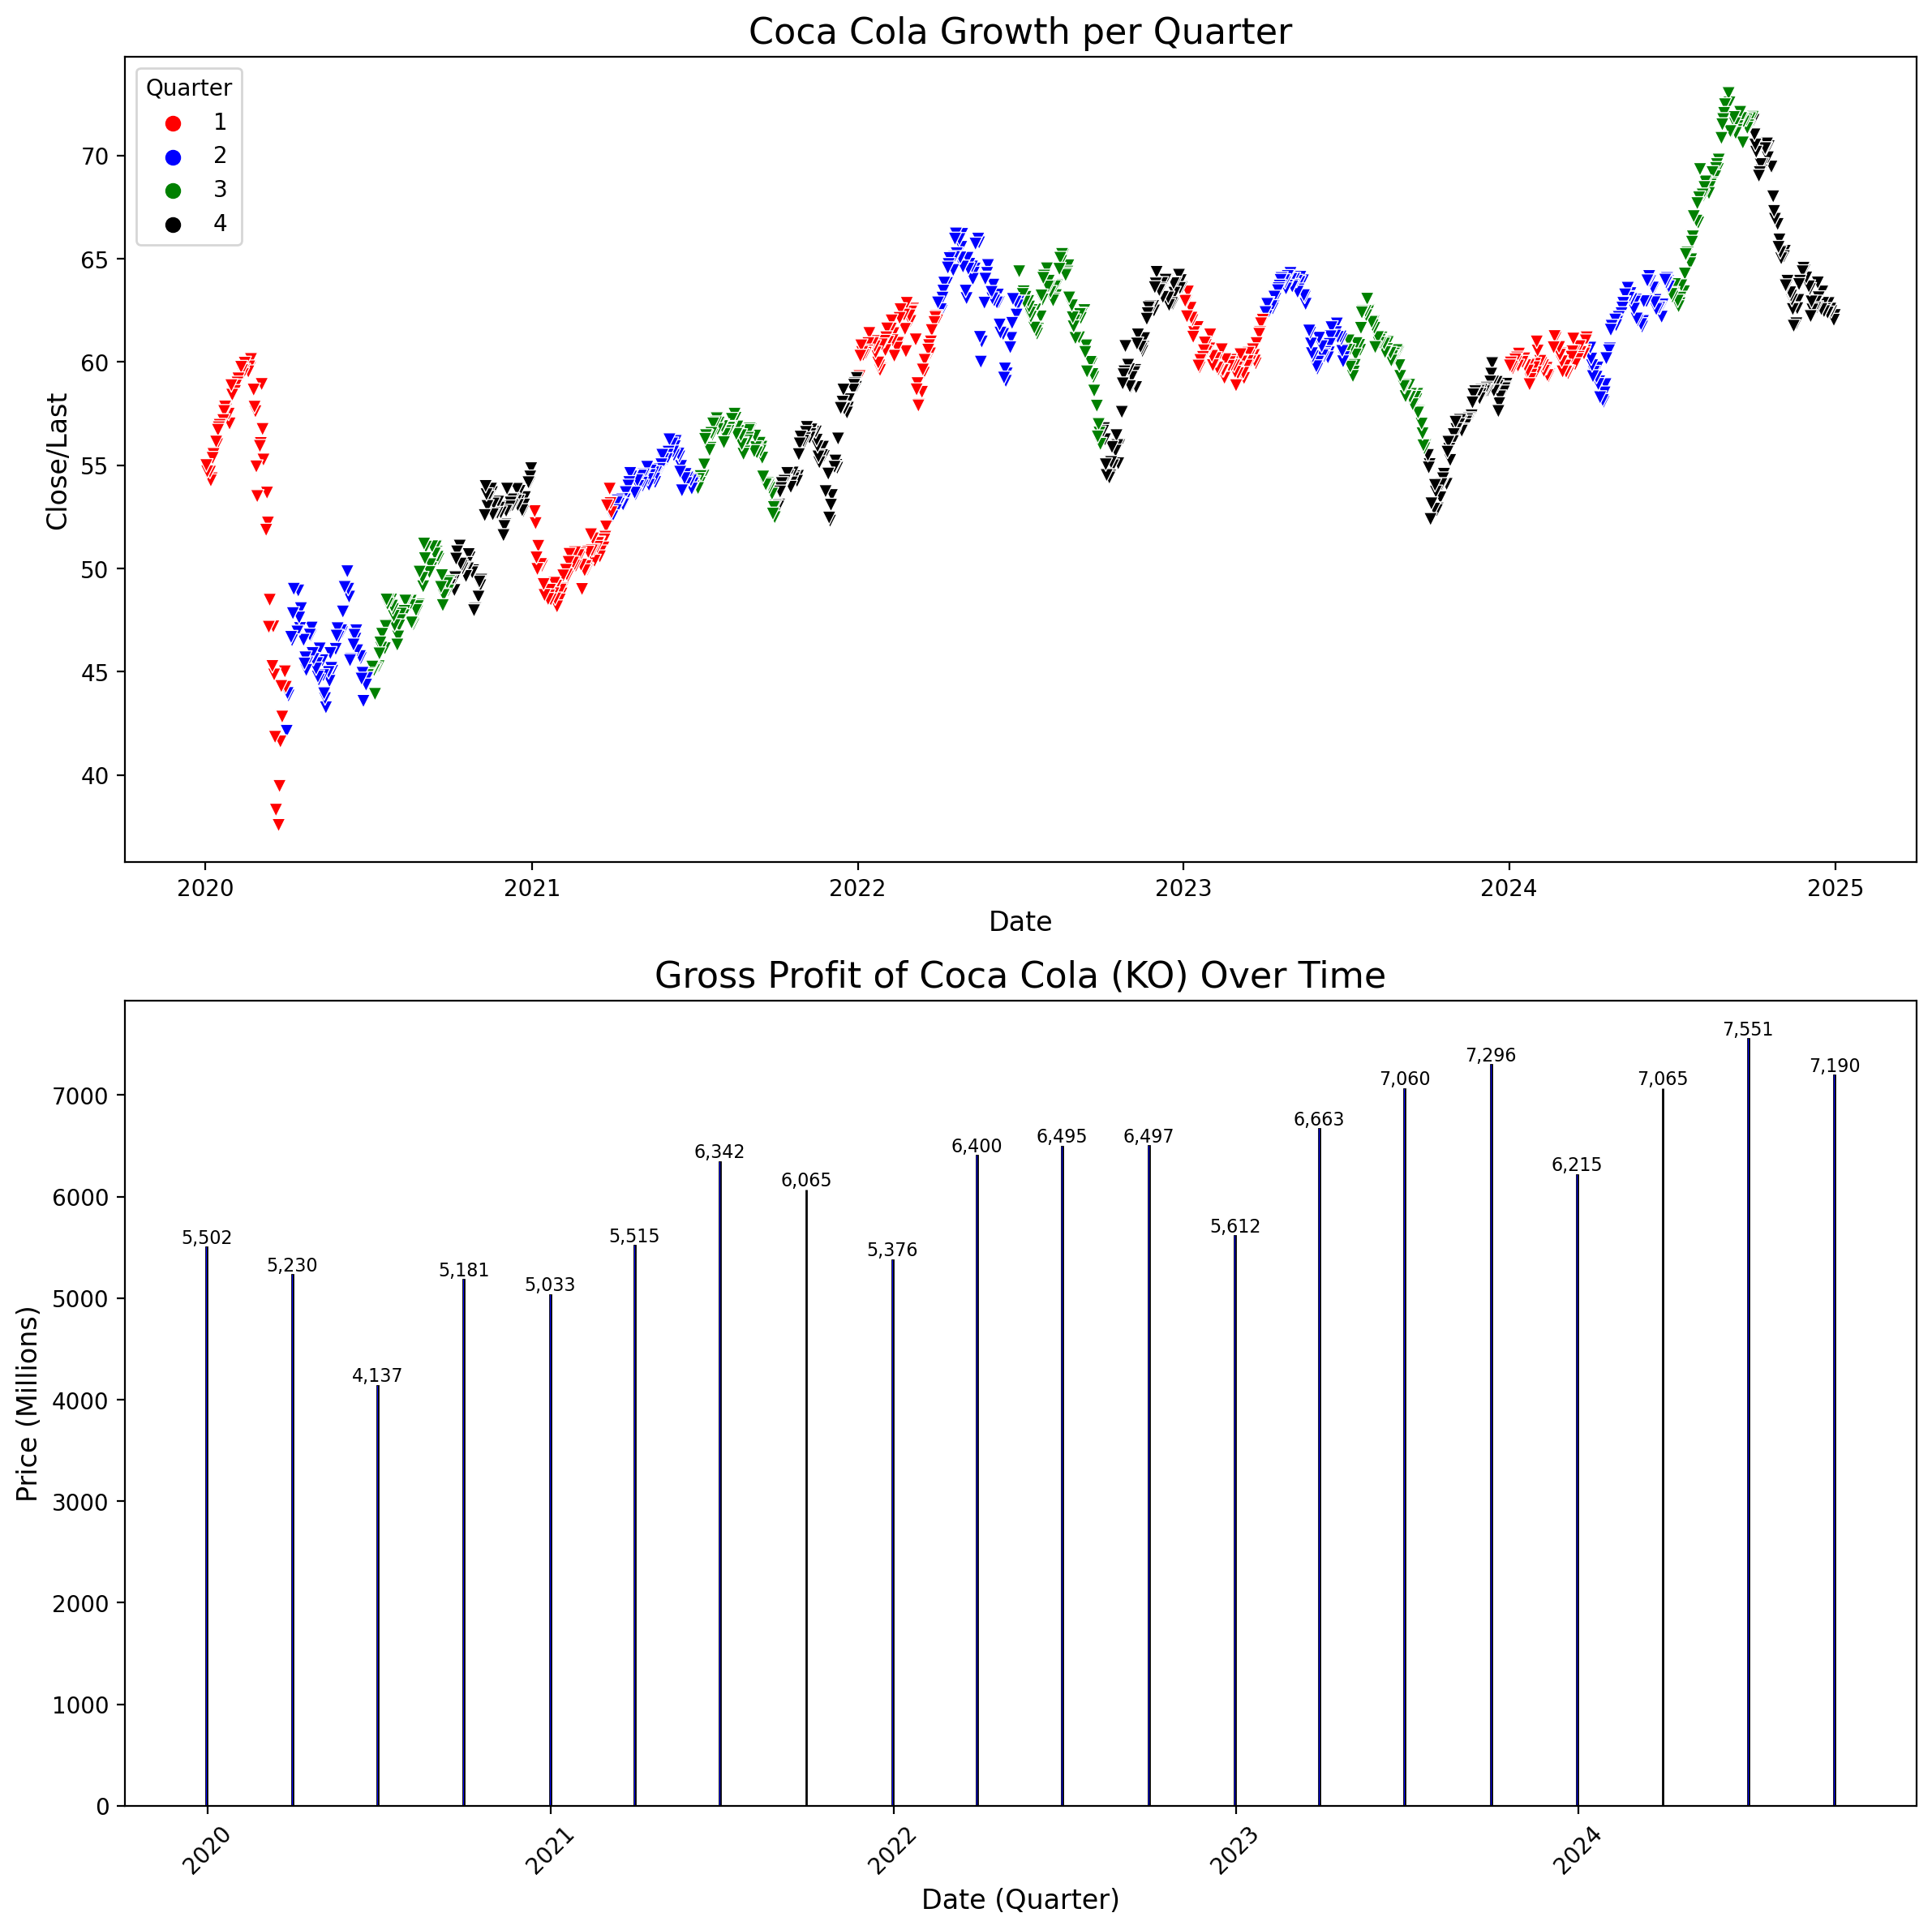

In [5]:
data['Quarter'] = data['Date'].dt.quarter
data2 = pd.read_csv('Gross Profit(KO).csv')

data2['Date (Quarter)'] = pd.to_datetime(data2['Date (Quarter)'])
data2['Price (Millions)'] = data2['Price (Millions)'].replace('[\$,]', '', regex=True).astype(int) 

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
custom_palette = {1: 'red', 2: 'blue', 3: 'green', 4: 'black'}
sns.scatterplot(
    data=data,
    x="Date",
    y="Close/Last",
    ax=axes[0],
    hue='Quarter',
    palette=custom_palette,
    marker='v'
)
axes[0].legend(title='Quarter', loc='upper left', fontsize=10)
axes[0].set_title("Coca Cola Growth per Quarter", fontsize=16)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Close/Last', fontsize=12)

bars = axes[1].bar(
    data2['Date (Quarter)'], 
    data2['Price (Millions)'], 
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] * (len(data2) // 4 + 1), 
    edgecolor='black'
)

axes[1].bar(data2['Date (Quarter)'], data2['Price (Millions)'], color='blue')
axes[1].set_title("Gross Profit of Coca Cola (KO) Over Time", fontsize=16)
axes[1].set_xlabel('Date (Quarter)', fontsize=12)
axes[1].set_ylabel('Price (Millions)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.0, 
        height, 
        f'{height:,}', 
        ha='center', 
        va='bottom', 
        fontsize=8)
    
plt.tight_layout()
plt.show()

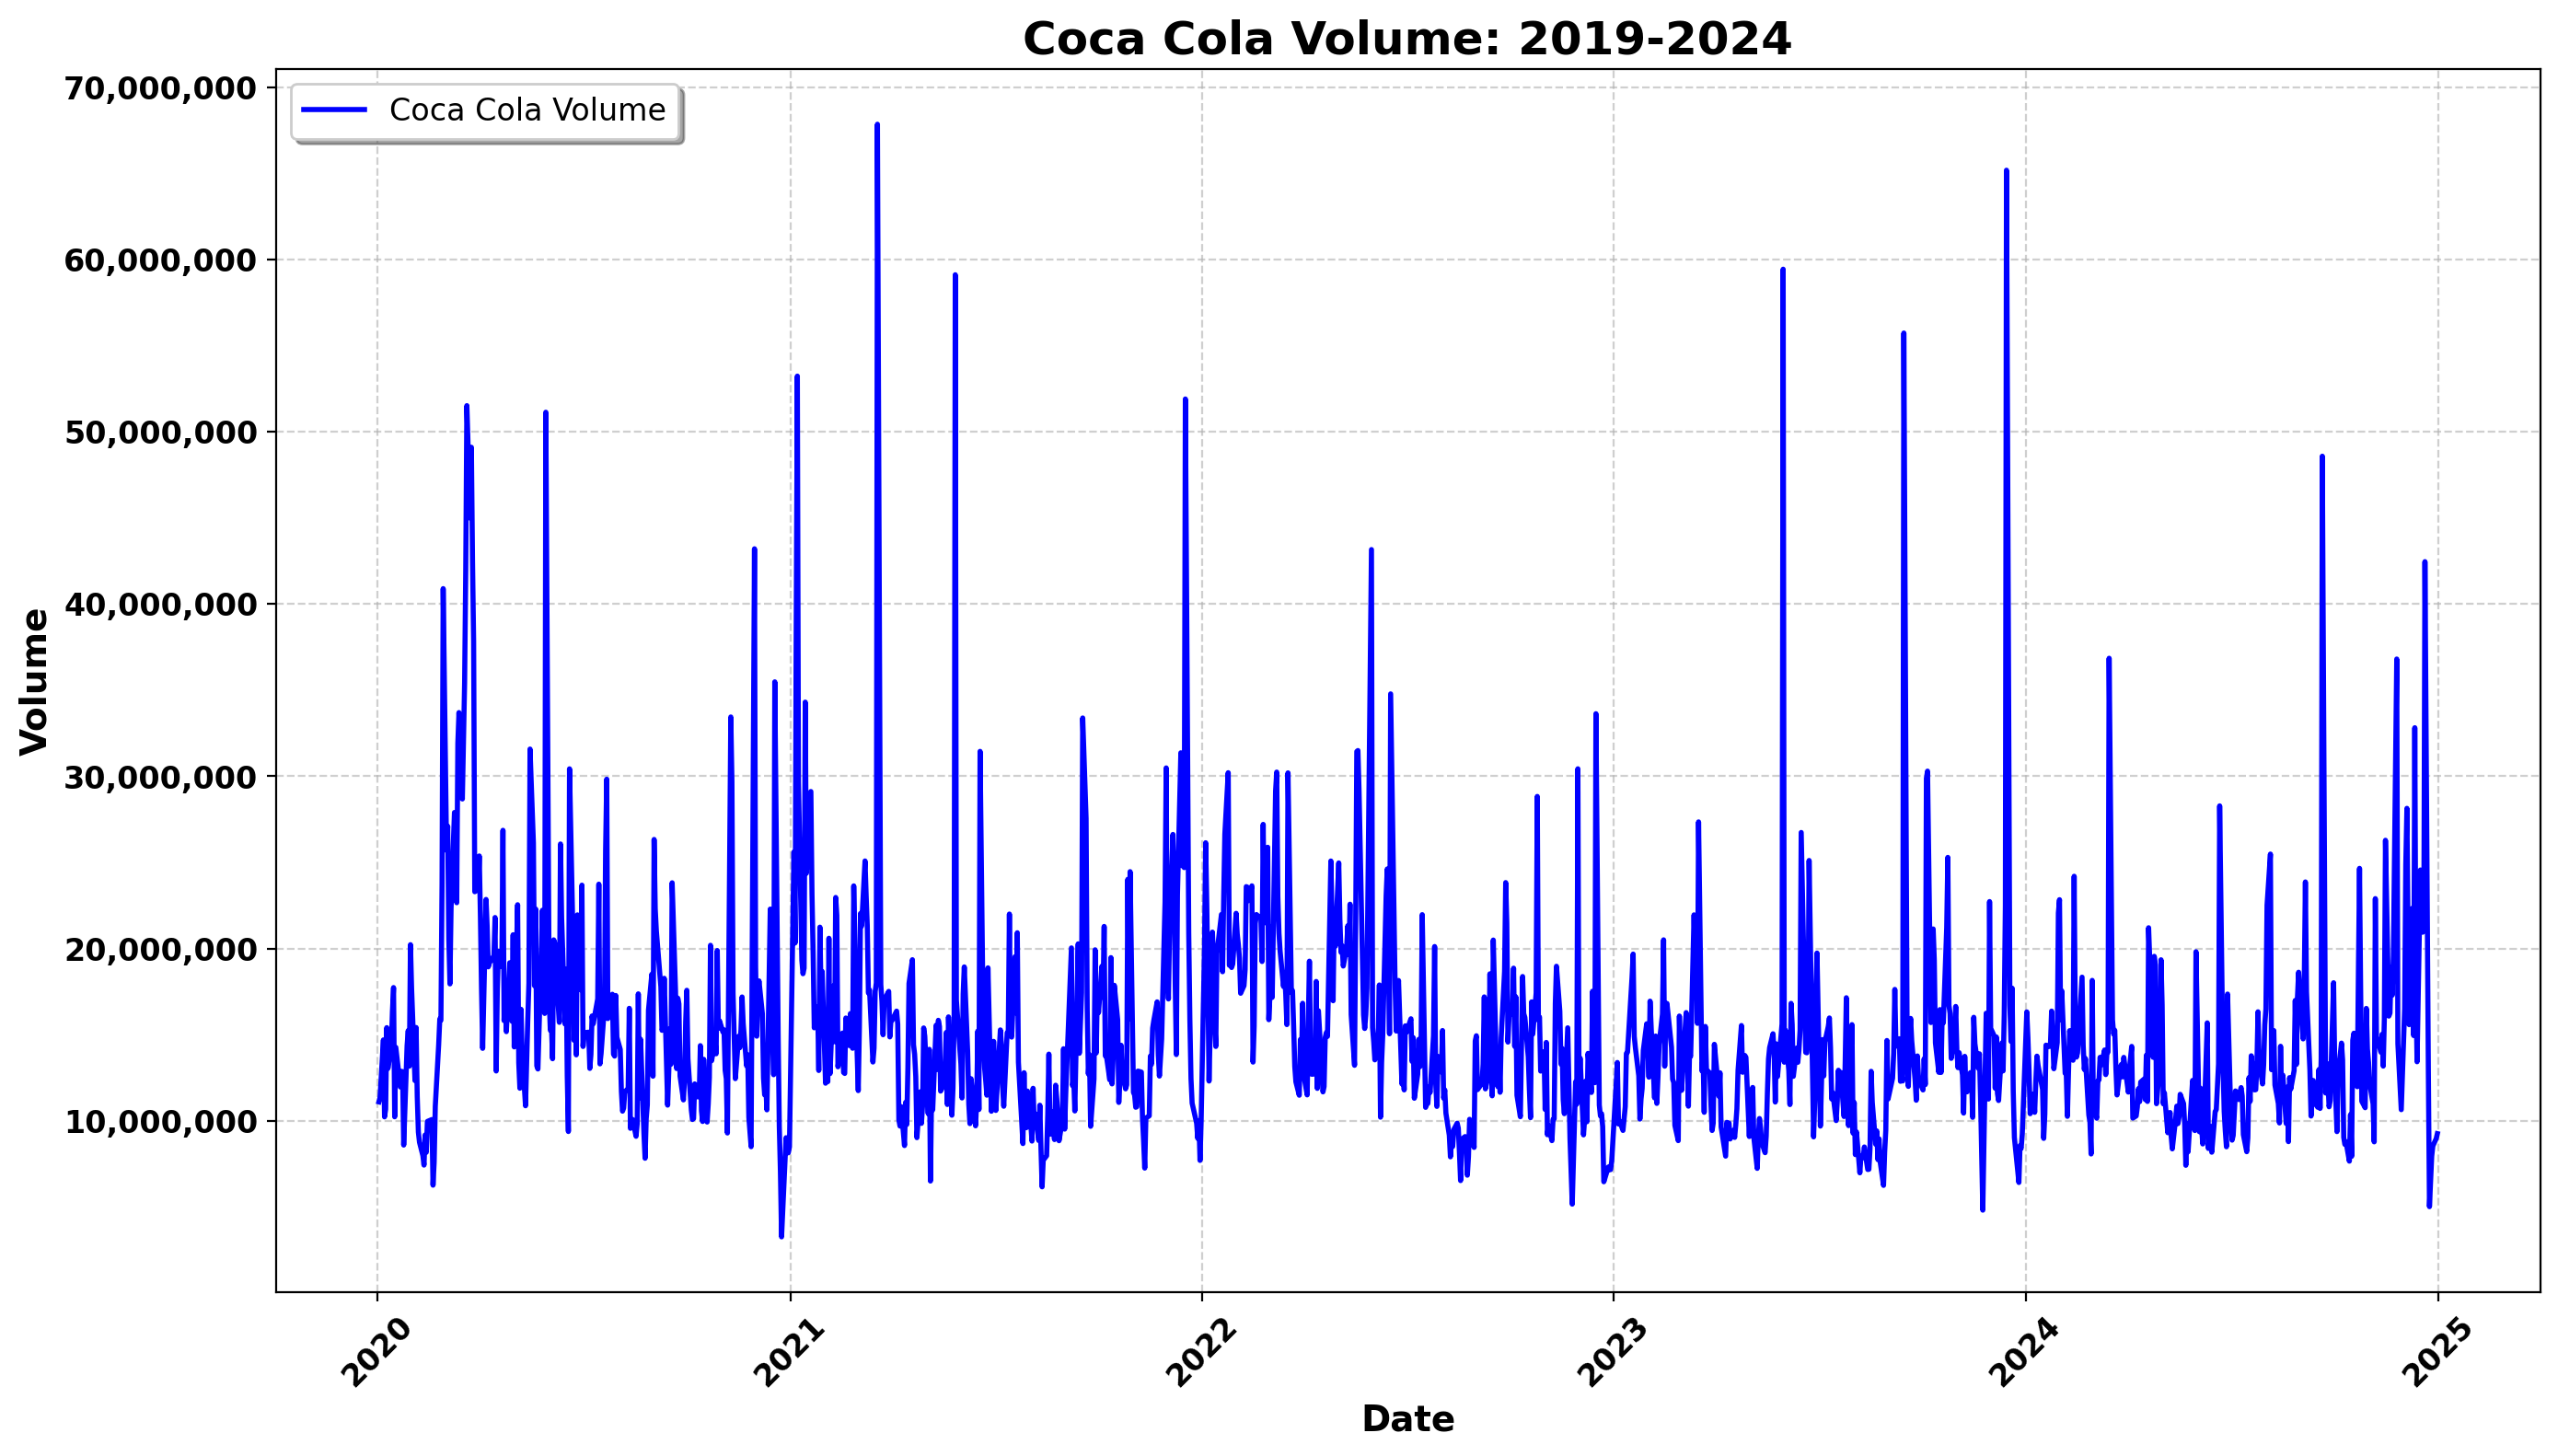

In [6]:
plt.figure(figsize=(14, 8))

plt.plot(data['Date'], 
    data['Volume'], 
    linewidth=2, 
    color='blue', 
    label='Coca Cola Volume')


plt.title('Coca Cola Volume: 2019-2024', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Volume', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12, rotation=45, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, fancybox=True)
plt.tight_layout()

plt.show()

If you take a look at these charts, Coca-Cola’s share price has generally been trending upward quarter by quarter, even though it dips here and there in response to broader market events. Meanwhile, the bar chart on gross profit shows a steady climb over the years, which hints at the company’s ability to keep expanding—even during challenging times. The volume chart also shows consistent interest from investors, with occasional spikes that often reflect news or announcements. Taken together, these visuals suggest that Coca-Cola has a track record of steady growth, reliable profitability, and ongoing demand from the market. While no stock is a sure thing, these signs point to Coca-Cola as a potentially solid pick for people looking for both stability and gradual growth in their portfolios.

22:31:00 - cmdstanpy - INFO - Chain [1] start processing
22:31:00 - cmdstanpy - INFO - Chain [1] done processing


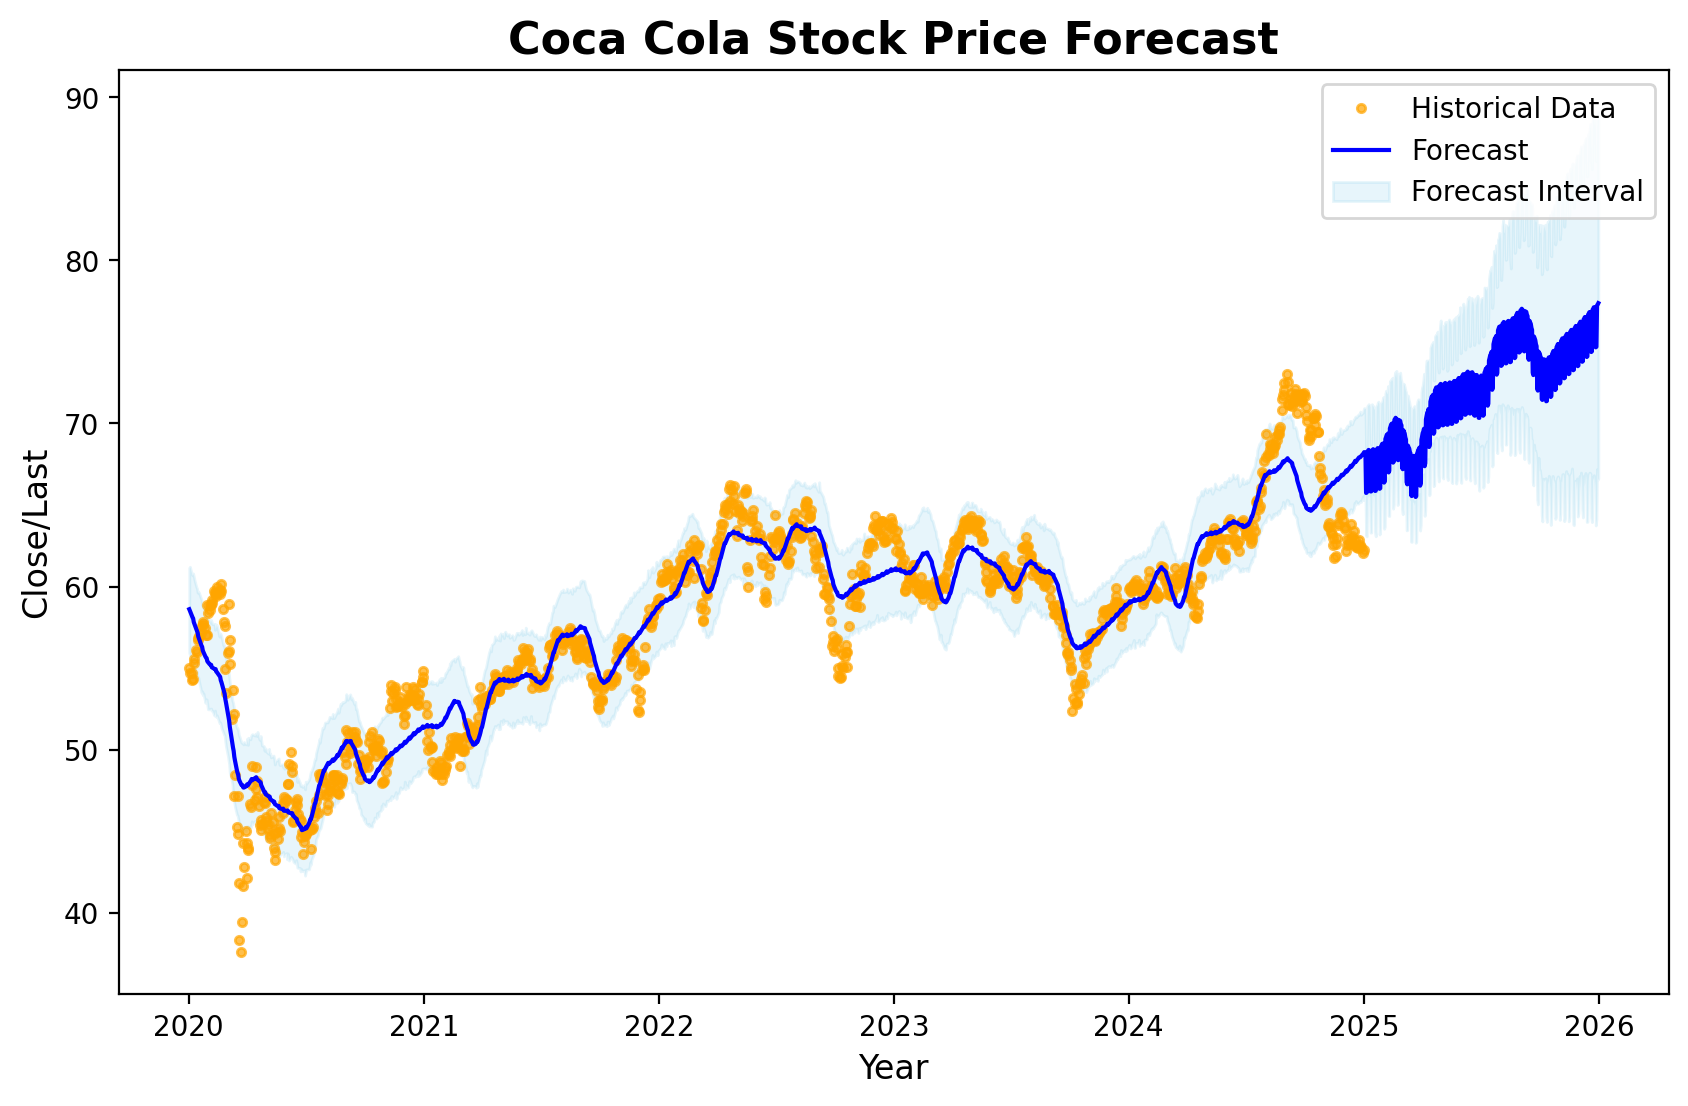

In [8]:
df = data[['Date', 'Close/Last']]
df = df.rename(columns={'Date': 'ds', 'Close/Last': 'y'})

model = Prophet() 
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

plt.figure(figsize=(10,6))
plt.plot(df['ds'], df['y'], '.', color='orange', label='Historical Data', alpha=0.7)
plt.plot(forecast['ds'], forecast['yhat'], 'b-', label='Forecast')

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='skyblue',      
    alpha=0.2,        
    label='Forecast Interval'
)

plt.title('Coca Cola Stock Price Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Close/Last', fontsize=12)
plt.legend()
plt.show()

From this forecast chart, it’s clear that Coca-Cola’s stock price has generally trended upward over the past few years, even though there were a few dips along the way—most notably around early 2020. You can see the historical data (in orange) following a consistent upward climb, showing how the brand has remained resilient despite market ups and downs. The blue line represents the model’s main forecast, while the lighter shaded area indicates the forecast interval, reflecting the model’s uncertainty about where the price could realistically end up.

Moving into 2024 and beyond, the forecast suggests a gradual but steady rise in Coca-Cola’s share price. However, we can also see the confidence interval widen as we look further into the future, which is typical for forecast models: the further out you predict, the more chance real-world factors can impact the numbers. This doesn’t necessarily mean Coca-Cola’s actual price will land on the high or low edge; it simply highlights the range of possibilities based on historical patterns and projected trends. Overall, the chart underlines Coca-Cola’s generally positive long-term outlook, but as with any stock, real-world variables—like consumer trends, macroeconomic shifts, or unexpected events—could influence the share price in ways the model can’t fully capture.